In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys

sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')

from scipy.stats import norm
from tkinter import *
import scipy
from scipy import signal

import platform
from glob import glob
from scipy.spatial import distance
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
import LL_funcs as LLf
import freq_funcs as ff
import h5py
import copy
#
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from tqdm.notebook import trange, tqdm

dist_groups = np.array([[0, 30], [30, 60], [60, 120]])
dist_labels = ['local (<30 mm)', 'short (<60mm)', 'long']
Fs = 500
dur = np.zeros((1, 2), dtype=np.int32)
t0 = 1
dur[0, 0] = -t0
dur[0, 1] = 3

folder = 'BrainMapping'
# dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax = np.arange(dur[0, 0], dur[0, 1], (1 / Fs))
color_elab = np.zeros((3, 3))
color_elab[0, :] = np.array([31, 78, 121]) / 255
color_elab[1, :] = np.array([189, 215, 238]) / 255
color_elab[2, :] = np.array([0.256, 0.574, 0.431])
cwd = os.getcwd()
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

In [2]:
subj = 'EL027'
cond_folder = 'CR'  # Condition = 'Hour', 'Condition', 'Ph'

if cond_folder == 'Ph':
    cond_vals = np.arange(4)
    cond_labels = ['BM', 'BL', 'Fuma', 'BZD']
    cond_colors = ['#494159', '#594157', "#F1BF98", "#8FB996"]
    cond1 = 'Condition'  # 'condition', 'h'
    cond_folder = 'Ph'  # 'Ph', 'Sleep', 'CR'
    Condition = 'Condition'
if cond_folder == 'CR':
    Condition = 'Hour'  # Condition = 'Hour'
    cond1 = 'h'  # h (as stored in stimlist)

######## General Infos

path_patient_analysis = sub_path+'\EvM\Projects\EL_experiment\Analysis\Patients\\' + subj
path_gen = os.path.join(sub_path+'\Patients\\' + subj)
if not os.path.exists(path_gen):
    path_gen = 'T:\\EL_experiment\\Patients\\' + subj
path_patient = path_gen + '\Data\EL_experiment'  # os.path.dirname(os.path.dirname(cwd))+'/Patients/'+subj
path_infos = os.path.join(path_gen, 'Electrodes')

Fs = 500

files_list = glob(path_patient_analysis + '\\' + folder + '/data/Stim_list_*')
i = 0
stimlist = pd.read_csv(files_list[i])
lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
if "type"in lbls:
    lbls = lbls[lbls.type=='SEEG']
    lbls = lbls.reset_index(drop=True)
labels_all, labels_region, labels_clinic, coord_all, StimChans, StimChanSM, StimChansC, StimChanIx, stimlist = bf.get_Stim_chans(
    stimlist,
    lbls)

labels_h = lbls.Hemisphere + '_' + labels_all


In [6]:
import mne

In [8]:
file_raw = os.path.join(path_gen, 'Data_raw', 'EL_experiment', 'EL027_BM01.EDF')

In [9]:
edf = mne.io.read_raw_edf(file_raw)

Extracting EDF parameters from X:\4 e-Lab\Patients\EL027\Data_raw\EL_experiment\EL027_BM01.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\i0328442\AppData\Local\Temp\ipykernel_6364\3467337933.py:1: RuntimeWarning: Omitted 3 annotation(s) that were outside data range.
  edf = mne.io.read_raw_edf(file_raw)


## RAW Monopolar

In [71]:
data_raw = edf.get_data(picks=edf.ch_names[0:12], units='uV')

In [36]:
FS_raw = edf.info['sfreq']

In [104]:
t_start = 100
t0 = int(t_start*FS_raw)
x_ax_raw = np.linspace(0, t, int(t*FS_raw))

In [125]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

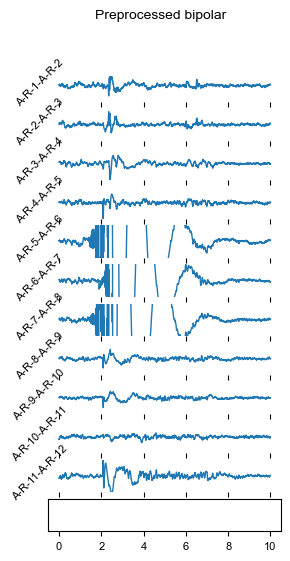

In [126]:
t0 = int(t_start*Fs)
x_ax_filt = np.linspace(0, t, int(t*Fs))

data_pp_sel = data_pp[:, t0:int(t0+t*Fs)]
fig, axs = plt.subplots(12, 1, figsize=(3, 6), sharex=True, sharey = True)
plt.suptitle('Preprocessed bipolar')
fig.patch.set_facecolor('xkcd:white')
for ch in range(11):
    ax = axs[ch]
    ax.plot(x_ax_filt, data_pp_sel[ch,:], lw=1)
    ax.set_ylabel(labels_clinic[ch], rotation = 45)
    ax.set_ylim([-800, 800])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
ax.set_xlabel('Time [s]')
plt.savefig('X:\\4 e-Lab\\EvM\Projects\EL_experiment\Analysis\Supp_figures\Schematics\\pp_BP.svg')

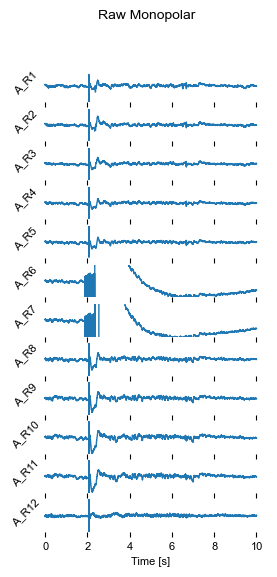

In [127]:
t0 = int(t_start*FS_raw)
data_raw_sel = data_raw[:, t0:int(t0+t*FS_raw)]
fig, axs = plt.subplots(12, 1, figsize=(3, 6), sharex=True, sharey = True)

plt.suptitle('Raw Monopolar')
fig.patch.set_facecolor('xkcd:white')
for ch in range(12):
    ax = axs[ch]
    ax.plot(x_ax_raw, data_raw_sel[ch, :], lw=1)
    ax.set_ylabel(edf.ch_names[ch], rotation = 45)
    ax.set_ylim([-1000, 1000])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
ax.set_xlabel('Time [s]')
plt.savefig('X:\\4 e-Lab\\EvM\Projects\EL_experiment\Analysis\Supp_figures\Schematics\\raw_MP.svg')

## Bipolar Raw

In [46]:
file_raw = os.path.join(path_gen, 'Data', 'EL_experiment', 'experiment1', 'data_blocks','EL027_BP_CR01','EL027_BP_CR01.mat')

In [56]:
data_BP = h5py.File(file_raw, 'r')['EEG']
data_BP = data_BP[()].T
data_BP

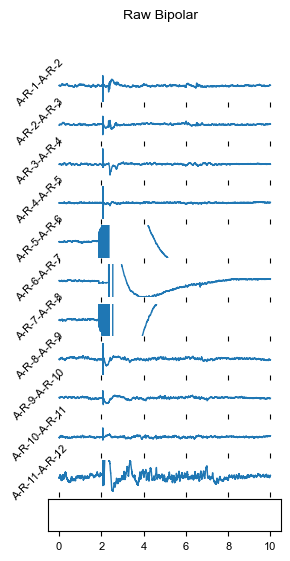

In [128]:
t0 = int(t_start*FS_raw)

data_BP_sel = data_BP[:, t0:int(t0+t*FS_raw)]
fig, axs = plt.subplots(12, 1, figsize=(3, 6), sharex=True, sharey = True)
plt.suptitle('Raw Bipolar')
fig.patch.set_facecolor('xkcd:white')
for ch in range(11):
    ax = axs[ch]
    ax.plot(x_ax_raw, data_BP_sel[ch,:], lw=1)
    ax.set_ylabel(labels_clinic[ch], rotation = 45)
    ax.set_ylim([-500, 500])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
ax.set_xlabel('Time [s]')
plt.savefig('X:\\4 e-Lab\\EvM\Projects\EL_experiment\Analysis\Supp_figures\Schematics\\raw_BP.svg')

In [65]:
data_art = h5py.File(file_raw, 'r')

In [66]:
file_raw = os.path.join(path_gen, 'Data', 'EL_experiment', 'experiment1', 'data_blocks','EL027_BP_CR01','EEG_art.mat')
data_art = h5py.File(file_raw, 'r')['EEG_art']
data_art = data_art[()].T
data_art = data_art[0:12,:]

## Preprocessed

In [83]:
file_raw = os.path.join(path_gen, 'Data', 'EL_experiment', 'experiment1', 'data_blocks','EL027_BP_CR01','ppEEG.mat')
data_pp = h5py.File(file_raw, 'r')['ppEEG']
data_pp = data_pp[()].T
data_pp = data_pp[0:12,:]

In [84]:
t0 = int(t_start*Fs)
x_ax_filt = np.linspace(0, t, int(t*Fs))

data_pp_sel = data_pp[:, t0:int(t0+t*Fs)]
fig, axs = plt.subplots(12, 1, figsize=(3, 6), sharex=True, sharey = True)
plt.suptitle('Preprocessed bipolar')
fig.patch.set_facecolor('xkcd:white')
for ch in range(11):
    ax = axs[ch]
    ax.plot(x_ax_filt, data_pp_sel[ch,:], lw=1)
    ax.set_ylabel(labels_clinic[ch], rotation = 45)
    ax.set_ylim([-800, 800])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
ax.set_xlabel('Time [s]')
plt.savefig('X:\\4 e-Lab\\EvM\Projects\EL_experiment\Analysis\Supp_figures\Schematics\\pp_BP.svg')

### ZOOM In

In [142]:
data_art_sel =  data_art[:, t0:int(t0+t*FS_raw)]

In [166]:
ch_sel_all = [1,2,3, 7, 8]

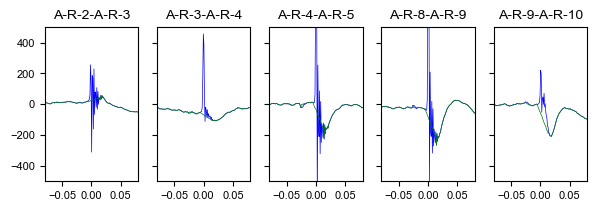

In [171]:
fig, axs = plt.subplots(1, len(ch_sel_all), figsize=(7,2), sharex=True, sharey = True)
for ch_ix, ch_sel in enumerate(ch_sel_all):
    shift = 2.07
    ax = axs[ch_ix]
    ax.plot(x_ax_raw-shift, data_BP_sel[ch_sel,:], lw=0.5, color='blue')
    ax.plot(x_ax_raw-shift, data_art_sel[ch_sel,:], lw=0.5, color='green')
    
    # ax.axvline(0, color='green')
    ax.set_title(labels_clinic[ch_sel])
ax.set_xlim([-0.08, 0.08])
ax.set_ylim([-500, 500])

plt.savefig('X:\\4 e-Lab\\EvM\Projects\EL_experiment\Analysis\Supp_figures\Schematics\\examples.svg')